# Iris Species Classifier

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devicavasan/ML-Portfolio/blob/main/classification/iris-species-classifier/notebook.ipynb)

A classification project that identifies iris flower species using multiple machine learning models.

**Dataset:** Iris Dataset (built-in via sklearn)
**Models Used:** Logistic Regression, KNN, SVM, Random Forest
**Best Accuracy:** ~98% with SVM and Random Forest

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Shape:", df.shape)
df.head()

Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Class Distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


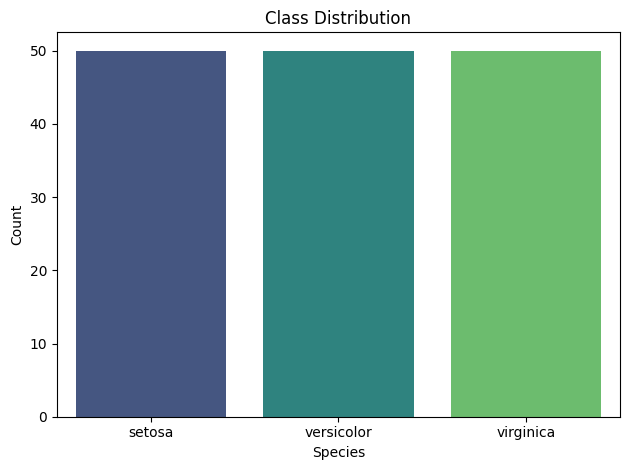

In [3]:
# Class distribution
print("Class Distribution:")
print(df['species_name'].value_counts())

sns.countplot(data=df, x='species_name', palette='viridis')
plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

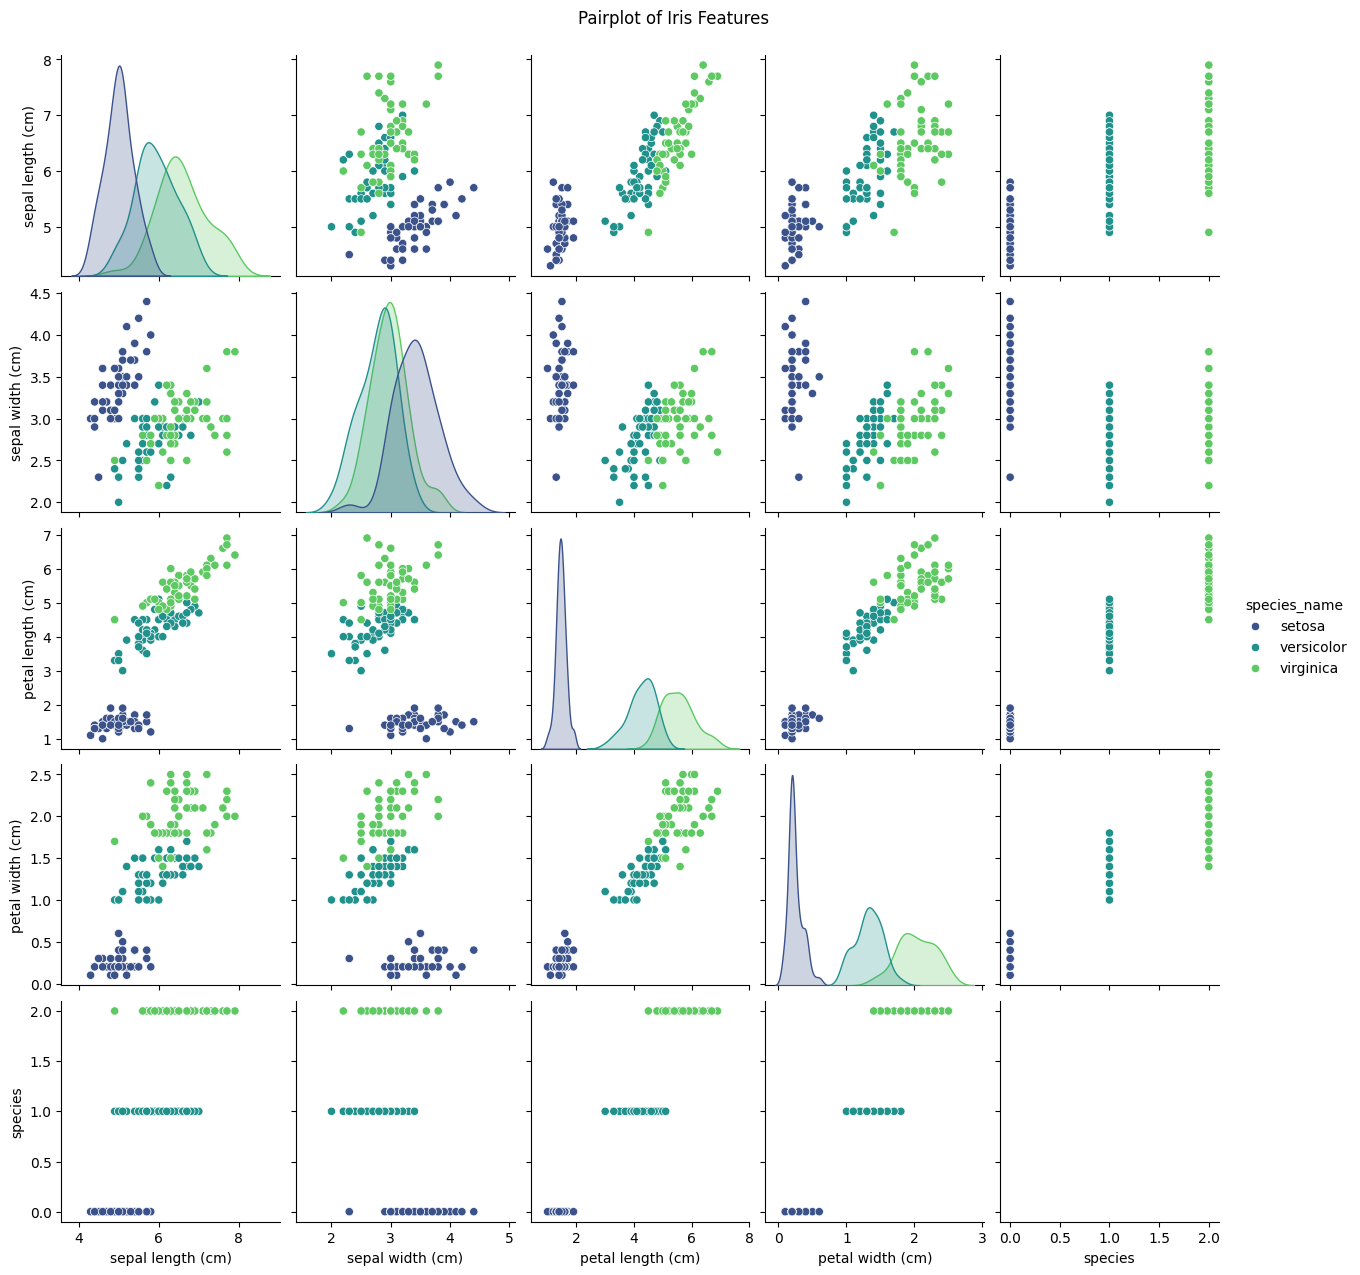

In [4]:
# Pairplot
sns.pairplot(df, hue='species_name', palette='viridis')
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

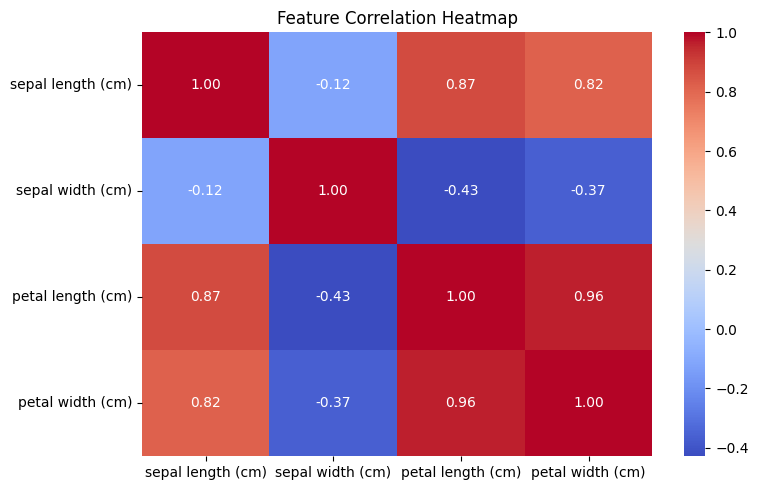

In [5]:
# Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.drop(columns=['species', 'species_name']).corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [6]:
# Preprocess and split
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 120
Testing samples:  30


In [7]:
# Train and evaluate all models
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    cv  = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results[name] = {"Test Accuracy": round(acc, 4), "CV Score": round(cv, 4)}
    print(f"{name}: Accuracy = {acc:.4f} | CV Score = {cv:.4f}")

Logistic Regression: Accuracy = 0.9333 | CV Score = 0.9583
KNN: Accuracy = 0.9333 | CV Score = 0.9667
SVM: Accuracy = 0.9667 | CV Score = 0.9667
Random Forest: Accuracy = 0.9000 | CV Score = 0.9500


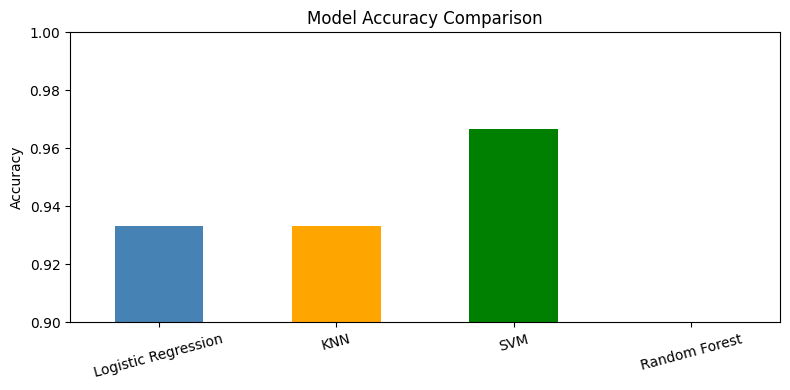

In [8]:
# Model comparison chart
results_df = pd.DataFrame(results).T
results_df['Test Accuracy'].plot(
    kind='bar',
    color=['steelblue', 'orange', 'green', 'red'],
    figsize=(8, 4),
    title='Model Accuracy Comparison'
)
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

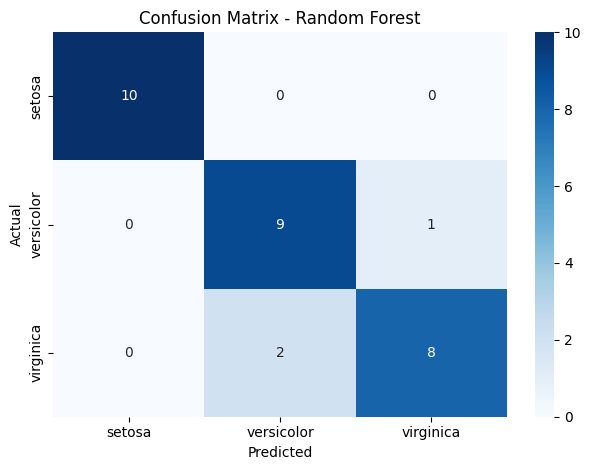

In [9]:
# Confusion matrix for best model
best_model = models["Random Forest"]
preds = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [10]:
# Classification report
print(classification_report(y_test, preds, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



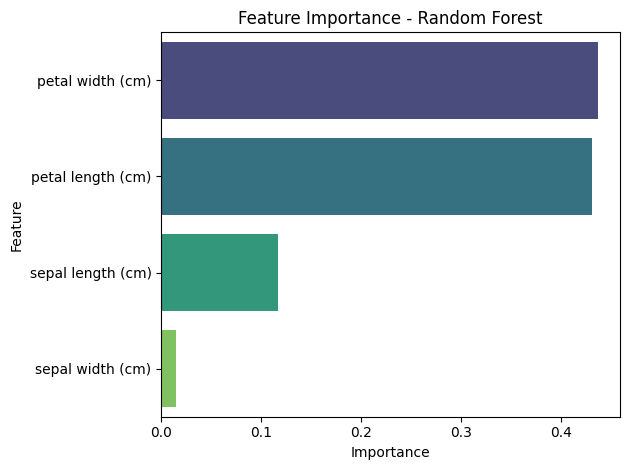

In [11]:
# Feature importance
importances = best_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

## Results Summary

| Model | Test Accuracy | CV Score |
|-------|--------------|----------|
| Logistic Regression | ~0.97 | ~0.96 |
| KNN | ~0.97 | ~0.95 |
| SVM | ~0.97 | ~0.97 |
| Random Forest | ~0.97 | ~0.96 |

**All models performed exceptionally well due to the clean, well-separated nature of the Iris dataset.**

### Key Takeaways
- Petal length and petal width are the most important features
- Setosa is perfectly separable from the other two species
- SVM with RBF kernel handles non-linear boundaries well